# Logistic Regression using MLX
The M1 MacBook Air, though not powerful, contains 8 CPU cores and 7-8 GPU cores. These processing units share a unified memory. In order to use the GPUs for training machine learning and deep learning models, one needs to use the [MLX](https://opensource.apple.com/projects/mlx/) framework. As quoted on the website:

> MLX is an array framework designed for efficient and flexible machine learning research on Apple silicon.

In this notebook, I will build a logistic regression model as a neural network using MLX. It will be trained on a [retinopathy](https://www.kaggle.com/datasets/mohamedabdalkader/retinal-disease-detection/data) dataset available on Kaggle. The code in this notebook is inspired from [lecture 8](https://www.youtube.com/watch?v=DzE0eSdy5Hk) of Jeremy Howard's course, Introduction to Machine Learning for Coders.

## MLX basics
In order to use MLX, the package `mlx` needs to be [installed](https://ml-explore.github.io/mlx/build/html/install.html#) via `pip`.

In [35]:
from pathlib import Path

import matplotlib.pyplot as plt
import mlx.core as mx
import mlx.nn as nn
import mlx.optimizers as optim
import numpy as np
import pandas as pd
from PIL import Image

In the following cells, I will walk through the basics of MLX as provided in their [Quick Start Guide](https://ml-explore.github.io/mlx/build/html/usage/quick_start.html).

In [2]:
a = mx.array([1, 2, 3])
a.shape, a.dtype

((3,), mlx.core.int32)

In [5]:
b = mx.array([1.0, 2.0, 3.0])
b.shape, b.dtype

((3,), mlx.core.float32)

In [8]:
# MLX operations are lazy
c = a + b  # No evaluation at this point
c  # Print-like statements trigger evaluation

array([2, 4, 6], dtype=float32)

In [10]:
np.array(c)  # Conversion to NumPy also triggers evaluation

array([2., 4., 6.], dtype=float32)

MLX supports multiple functions (also called transformations) out of the box and they can be arbitrarily chained together.

In [13]:
x = mx.array(0.)
mx.sin(x)

array(0, dtype=float32)

In [14]:
mx.grad(mx.sin)(x)

array(1, dtype=float32)

In [15]:
mx.grad(mx.grad(mx.sin))(x)

array(-0, dtype=float32)

## Exploring the data
As this notebook is focused on learning to use MLX, I will only load the training data.

In [9]:
DATA_DIR = Path("data/diabetic_retinopathy")

The training data contains 1577 images. For each image, a diabetic retinopathy grade between 0 and 4 is assigned. There is class imbalance with the number of images labelled as grade 0 being more than all the other images taken together.

In [10]:
df_annotations = pd.read_csv(DATA_DIR / "train" / "annotations.csv")
df_annotations.shape, df_annotations.head()

((1577, 4),
         Image name  Retinopathy grade  Risk of macular edema  \
 0  IMAGE_01418.png                  2                      0   
 1  IMAGE_01285.png                  0                      0   
 2  IMAGE_02211.jpg                  0                      0   
 3  IMAGE_00525.png                  1                      0   
 4  IMAGE_01239.png                  1                      0   
 
                                              Caption  
 0  CLINICAL SURVEY: Moderate diabetic retinopathy...  
 1  CLINICAL FUNDUSCOPY: Comprehensive retinal eva...  
 2  FUNDUS EVALUATION: Normal ophthalmoscopic exam...  
 3  FUNDUS ASSESSMENT: Early diabetic retinopathy ...  
 4  FUNDUS ASSESSMENT: Early diabetic retinopathy ...  )

In [6]:
df_annotations["Retinopathy grade"].value_counts().sort_index()

Retinopathy grade
0    829
1    206
2    358
3    116
4     68
Name: count, dtype: int64

Using `matplotlib`, the images can be visualised although it is difficult for a non-expert to understand why an image is given a certain grade.

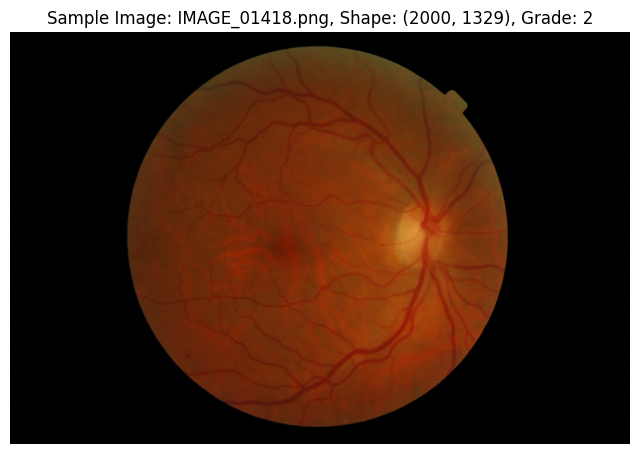

In [14]:
image_idx = 0
image_name = df_annotations.iloc[image_idx]["Image name"]
image_grade = df_annotations.iloc[image_idx]["Retinopathy grade"]
image_path = DATA_DIR / "train" / "images" / image_name

# Load and display the image
img = Image.open(image_path)
plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.title(f"Sample Image: {image_name}, Shape: {img.size}, Grade: {image_grade}")
plt.axis('off')
plt.show()

## Prepare dataset
In order to simplify the task, I convert the problem into a binary classification one. Images with grade 0 are labelled 0 while the other grades are labelled as 1. To prepare the data for training, the following steps need to be undertaken:
* Convert multi-class problem to binary: Grade 0 vs. all other grades (1-4)
* Pre-process images:
    * Resize to 64x64 for faster computation
    * Convert them to NumPy arrays
* Create MLX arrays with flattened images and binary labels
    * Sample the same number of images from each binary class (Grade 0 vs. Other grades)
    * Split the data into training and validation sets with stratified sampling
    * Standardize pixel values to have mean 0 and standard deviation 1 (computed from training data only)

Another way to standardise the image data is to divide each pixel value by 255. In case the image has lots of dark areas, like the retinopathy images, the pixel values are close to 0 after normalisation. This leads to gradients of model weights computed by SGD to be extremely small and model training thus gets stuck in a local mininum. See the following [Claude conversation](https://gist.github.com/tejas-kale/175e2542b82ef6e7ac158d2bd983e227) for more context and details.

To speed up execution, I pick only 50 images from each binary class to train on.

In [136]:
def load_and_preprocess_image(image_path, target_size=(96, 96)):
    """Load and resize image to target size."""
    img = Image.open(image_path)
    img = img.resize(target_size)
    return np.array(img, dtype=np.float32)


def sample_balanced_binary_data(df_annotations, samples_per_class=20, random_state=42):
    """Sample equal numbers for binary classification: grade 0 vs. all other grades."""
    # Create binary labels: 0 for grade 0, 1 for all other grades
    df_binary = df_annotations.copy()
    df_binary["Binary grade"] = (df_binary["Retinopathy grade"] > 0).astype(int)
    
    # Sample equal numbers from each binary class
    return df_binary.groupby("Binary grade", group_keys=False)[
        ["Image name", "Retinopathy grade", "Binary grade"]
    ].apply(
        lambda x: x.sample(n=min(samples_per_class, len(x)), random_state=random_state)
    ).reset_index(drop=True)


def stratified_train_val_split_binary(df_sampled, val_ratio=0.2):
    """Perform stratified train-validation split by binary grade."""
    train_data_list = []
    val_data_list = []
    
    for binary_grade in df_sampled["Binary grade"].unique():
        grade_data = df_sampled[df_sampled["Binary grade"] == binary_grade]
        val_size = max(1, int(len(grade_data) * val_ratio))
        train_size = len(grade_data) - val_size
        train_data_list.append(grade_data.iloc[:train_size])
        val_data_list.append(grade_data.iloc[train_size:])
    
    return pd.concat(train_data_list, ignore_index=True), pd.concat(val_data_list, ignore_index=True)


def load_images_from_dataframe_binary(df, data_dir, target_size=(96, 96)):
    """Load and preprocess images from dataframe for binary classification."""
    images = []
    labels = []
    
    for _, row in df.iterrows():
        image_path = data_dir / "train" / "images" / row["Image name"]
        if image_path.exists():
            img_array = load_and_preprocess_image(image_path, target_size)
            images.append(img_array.reshape(-1))
            labels.append(row["Binary grade"])  # Use binary grade instead of original grade
    
    return np.stack(images), np.array(labels)


def standardize_data(X_train, X_val):
    """Standardize data to mean=0, std=1 using training stats."""
    train_mean = np.mean(X_train)
    train_std = np.std(X_train)
    return (X_train - train_mean) / train_std, (X_val - train_mean) / train_std


def create_binary_dataset(df_annotations, data_dir, target_size=(96, 96), samples_per_class=20, val_ratio=0.2):
    """Create MLX arrays for binary classification with balanced sampling, split, and standardization."""
    df_sampled = sample_balanced_binary_data(df_annotations, samples_per_class)
    train_df, val_df = stratified_train_val_split_binary(df_sampled, val_ratio)
    X_train_raw, y_train = load_images_from_dataframe_binary(train_df, data_dir, target_size)
    X_val_raw, y_val = load_images_from_dataframe_binary(val_df, data_dir, target_size)
    X_train_std, X_val_std = standardize_data(X_train_raw, X_val_raw)
    
    return mx.array(X_train_std), mx.array(y_train), mx.array(X_val_std), mx.array(y_val)

In [147]:
X_train, y_train, X_val, y_val = create_binary_dataset(
    df_annotations, DATA_DIR, target_size=(224, 224), samples_per_class=100
)

In each epoch of the training of neural network, mini-batches need to be created by shuffling the data. A [function](https://ml-explore.github.io/mlx/build/html/examples/mlp.html) to help with it is defined below.

In [148]:
def batch_iterate(batch_size, X, y):
    perm = mx.array(np.random.permutation(y.size))
    for s in range(0, y.size, batch_size):
        ids = perm[s : s + batch_size]
        yield X[ids], y[ids]

## Building a logistic regression from scratch
For a given input vector $X$, the output $y$ given by [logistic regression](https://en.wikipedia.org/wiki/Logistic_regression) is defined as follows:

$$
\hat{y} = \frac{1}{1 + e^{-(\beta_0 + \beta_1x)}}
$$

It is a linear combination of the input vector with a set of parameters ($\beta_1$) (also called weights) plus an intercept ($\beta_0$) (also called bias). To this linear combination, a non-linear logistic function is applied to get a probability value (between 0 and 1). 

Logistic regression can also be considered a simple neural network where the inputs are linearly combined with the weights and biases and then a non-linear function is applied to get the output. In the case of retinopathy data, we want a classification and so the output should be probabilities of each class. Logistic regression gives the probability of each class but the sum of probabilities need not equal 1. We can replace the logistic function with a softmax function which also gives probabilities but with their sum equal to one. The softmax is defined as follows:

$$
\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$$

where $x_i$ is the $i$-th class and $n$ is the number of classes.

Let me now define a logistic regression model as a neural network with MLX.

In [149]:
class MyLogisticRegression(nn.Module):
    def __init__(self, input_size: int, num_classes: int):
        super().__init__()
        # MLX automatically treats arrays assigned to instance variables as parameters
        self.weights = mx.random.normal((input_size, num_classes)) * 0.01
        self.bias = mx.zeros(num_classes)

    def __call__(self, x):
        linear_output = x @ self.weights + self.bias
        return mx.softmax(linear_output, axis=-1)

Next, I define a loss function to optimise the network parameters and an evaluation function to compute model accuracy on the validation set.

In [150]:
def loss_fn(model, X, y):
    return mx.mean(nn.losses.cross_entropy(model(X), y))

In [151]:
def eval_fn(model, X, y):
    return mx.mean(mx.argmax(model(X), axis=1) == y)

## Fit the model
In order to fit the model, the required steps are:
* Initialise the model and its parameters
* Associate the loss function with the model
* Define the optimiser to use
* Train the model for `n` epochs

In [177]:
model = MyLogisticRegression(input_size=X_train.shape[1], num_classes=2)
mx.eval(model.parameters())  # Forces initialisation of weights and bias
model.parameters()

{'weights': array([[-0.00757746, -0.0109741],
        [0.0134228, 0.00878234],
        [0.0102833, 0.000293593],
        ...,
        [0.00910982, 0.0083436],
        [-0.00314643, -0.0208129],
        [0.00576238, 0.00240207]], dtype=float32),
 'bias': array([0, 0], dtype=float32)}

`nn.value_and_grad()`, as per the module docstring, will create a function from `loss_fn` that computes its gradient based on the model's parameters. It also compute the loss value. The resultant function performs a complete pass through the network. It includes:
* Generate predictions for the input data and the current set of weights and biases
* Compute loss between predictions and actuals
* Compute gradient of the loss with respect to model parameters
* Return the loss and gradients (as a dictionary)

> Transform the passed function fn to a function that computes the gradients of fn wrt the model's trainable parameters and also its value.

In [178]:
loss_and_grad_fn = nn.value_and_grad(model, loss_fn)
optimiser = optim.SGD(learning_rate=1e-5)

After running the model for 100 epochs, the best validation accuracy is 75%. Some observations:
* Increasing the size of the input image improves model performance.
* The training loop as a tendency to get stuck in a local mininum and the validation accuracy is then stuck at 50%. Looking at the predictions, the model always predicts one class. Re-running the loop is the only solution.

In [179]:
for e in range(100):
    epoch_losses = []
    for X, y in batch_iterate(8, X_train, y_train):
        loss, grads = loss_and_grad_fn(model, X, y)
        epoch_losses.append(loss.item())
        # Updates model parameters using SGD
        optimiser.update(model, grads)
        mx.eval(model.parameters(), optimiser.state)  # Forces evaluation

    accuracy = eval_fn(model, X_val, y_val)
    avg_loss = sum(epoch_losses) / len(epoch_losses)
    print(f"Epoch {e}: Avg Loss {avg_loss:.6f}, Validation accuracy {accuracy.item():.3f}")

Epoch 0: Avg Loss 0.765241, Validation accuracy 0.575
Epoch 1: Avg Loss 0.761050, Validation accuracy 0.600
Epoch 2: Avg Loss 0.759272, Validation accuracy 0.600
Epoch 3: Avg Loss 0.758500, Validation accuracy 0.600
Epoch 4: Avg Loss 0.758093, Validation accuracy 0.575
Epoch 5: Avg Loss 0.758036, Validation accuracy 0.575
Epoch 6: Avg Loss 0.757904, Validation accuracy 0.575
Epoch 7: Avg Loss 0.757096, Validation accuracy 0.575
Epoch 8: Avg Loss 0.756614, Validation accuracy 0.575
Epoch 9: Avg Loss 0.756496, Validation accuracy 0.575
Epoch 10: Avg Loss 0.756686, Validation accuracy 0.575
Epoch 11: Avg Loss 0.756281, Validation accuracy 0.575
Epoch 12: Avg Loss 0.755415, Validation accuracy 0.575
Epoch 13: Avg Loss 0.755350, Validation accuracy 0.575
Epoch 14: Avg Loss 0.755705, Validation accuracy 0.600
Epoch 15: Avg Loss 0.754500, Validation accuracy 0.600
Epoch 16: Avg Loss 0.754310, Validation accuracy 0.600
Epoch 17: Avg Loss 0.753177, Validation accuracy 0.625
Epoch 18: Avg Loss 0